# AI Programming Foundations Project: Data Workflow

**Name:** Vasileios Panagiotopoulos

**Dataset:** Titanic passengers (891 rows, 15 columns), from the
[seaborn-data repository](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv),
a version of the [Kaggle Titanic dataset](https://www.kaggle.com/c/titanic/data).

This project builds a reproducible data workflow for the Titanic passenger data:
loading, cleaning, exploring and visualizing it. The goal is to find out which
passenger characteristics (sex, class, age, fare) are linked to survival, using
small reusable functions so every step can be rerun from scratch.

In [1]:
# Task 4: import libraries and load the dataset
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("titanic.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Task 5: Data cleaning functions

Problems found in the raw data:
- `deck` is missing for most passengers.
- `age` is missing for about 20% of passengers.
- `embarked` / `embark_town` are missing for 2 passengers.
- Several columns repeat information held in another column
  (`class` = `pclass`, `alive` = `survived`, `embark_town` = `embarked`,
  `who` / `adult_male` are derived from `sex` and `age`).

In [2]:
def report_missing(df):
    """Return a table with the count and percentage of missing values per column,
    showing only columns that have at least one missing value."""
    missing = df.isna().sum()
    table = pd.DataFrame({
        "missing": missing,
        "percent": (missing / len(df) * 100).round(1),
    })
    return table[table["missing"] > 0].sort_values("missing", ascending=False)


def drop_redundant_columns(df, max_missing_pct=50):
    """Drop columns that duplicate another column, plus any column whose share of
    missing values is above `max_missing_pct`. Returns a new DataFrame."""
    redundant = ["class", "alive", "embark_town", "who", "adult_male"]
    too_sparse = [c for c in df.columns if df[c].isna().mean() * 100 > max_missing_pct]
    to_drop = [c for c in redundant + too_sparse if c in df.columns]
    return df.drop(columns=to_drop)


def impute_age_by_group(df, group_cols=("pclass", "sex")):
    """Fill missing ages with the median age of passengers in the same group
    (by default class and sex), and add an `age_was_missing` flag so the
    imputed rows can still be identified later. Returns a new DataFrame."""
    out = df.copy()
    out["age_was_missing"] = out["age"].isna()
    group_median = out.groupby(list(group_cols))["age"].transform("median")
    out["age"] = out["age"].fillna(group_median)
    return out


def fill_embarked(df):
    """Fill missing port of embarkation with the most common port (the mode).
    Returns a new DataFrame."""
    out = df.copy()
    out["embarked"] = out["embarked"].fillna(out["embarked"].mode()[0])
    return out


def clean_titanic(df):
    """Run the full cleaning pipeline in a fixed order and return the cleaned data."""
    return (
        df.pipe(drop_redundant_columns)
          .pipe(impute_age_by_group)
          .pipe(fill_embarked)
    )

In [3]:
print("Missing values before cleaning:")
print(report_missing(df_raw))

df = clean_titanic(df_raw)

print("\nMissing values after cleaning:")
print(report_missing(df) if not report_missing(df).empty else "none")
print("\nShape before:", df_raw.shape, "| after:", df.shape)
print("Ages imputed:", int(df["age_was_missing"].sum()))
df.head()

Missing values before cleaning:
             missing  percent
deck             688     77.2
age              177     19.9
embarked           2      0.2
embark_town        2      0.2

Missing values after cleaning:
none

Shape before: (891, 15) | after: (891, 10)
Ages imputed: 177


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_was_missing
0,0,3,male,22.0,1,0,7.2500,S,False,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,True,False
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,False


Note on duplicates: this version of the dataset has no passenger name or ID,
so `df.duplicated()` flags rows that just share the same attributes. These are
most likely different people, so duplicate rows are **not** dropped.

In [4]:
print("Rows identical to another row:", int(df_raw.duplicated().sum()))

Rows identical to another row: 107


## Task 6: Exploratory analysis functions

In [5]:
def summarize_numeric(df, cols=("age", "fare", "sibsp", "parch")):
    """Return summary statistics (count, mean, std, min, quartiles, max) for the
    given numeric columns."""
    return df[list(cols)].describe().T.round(2)


def survival_rate_by(df, *group_cols):
    """Return the number of passengers and the survival rate (%) for each
    combination of the given grouping columns."""
    return (
        df.groupby(list(group_cols), observed=True)["survived"]
          .agg(passengers="count", survival_rate="mean")
          .assign(survival_rate=lambda t: (t["survival_rate"] * 100).round(1))
    )


def correlation_with_survival(df):
    """Return the Pearson correlation of each numeric column with `survived`,
    sorted from strongest positive to strongest negative."""
    numeric = df.select_dtypes(include=[np.number, "bool"]).astype(float)
    return numeric.corr()["survived"].drop("survived").sort_values(ascending=False).round(3)

**Table 1.** Overall survival rate and summary statistics for the numeric columns.

In [6]:
print("Overall survival rate: {:.1f}%".format(df["survived"].mean() * 100))
summarize_numeric(df)

Overall survival rate: 38.4%


,count,mean,std,min,25%,50%,75%,max
age,891.0,29.11,13.30,0.42,21.50,26.00,36.0,80.00
fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33
sibsp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00


**Table 2.** Survival by sex.

In [7]:
survival_rate_by(df, "sex")

,passengers,survival_rate
sex,,
female,314,74.2
male,577,18.9


**Table 3.** Survival by passenger class.

In [8]:
survival_rate_by(df, "pclass")

,passengers,survival_rate
pclass,,
1,216,63.0
2,184,47.3
3,491,24.2


**Table 4.** Survival by passenger class and sex.

In [9]:
survival_rate_by(df, "pclass", "sex")

passengers  survival_rate
pclass sex                              
1      female          94           96.8
       male           122           36.9
2      female          76           92.1
       male           108           15.7
3      female         144           50.0
       male           347           13.5

**Table 5.** Correlation of the numeric columns with survival.

In [10]:
correlation_with_survival(df)

fare               0.257
parch              0.082
sibsp             -0.035
age               -0.060
age_was_missing   -0.092
alone             -0.203
pclass            -0.338
Name: survived, dtype: float64

**Table 6.** Median and mean fare by passenger class.

In [11]:
df.groupby("pclass")["fare"].agg(median="median", mean="mean").round(2)

,median,mean
pclass,,
1,60.29,84.15
2,14.25,20.66
3,8.05,13.68


**Table 7.** Survival by age group (recorded ages only, imputed ages excluded).

In [12]:
age_bands = [0, 12, 18, 35, 60, 81]
age_labels = ["0-11", "12-17", "18-34", "35-59", "60+"]
known_ages = df[~df["age_was_missing"]].assign(
    age_group=lambda t: pd.cut(t["age"], bins=age_bands, labels=age_labels, right=False))
survival_rate_by(known_ages, "age_group")

,passengers,survival_rate
age_group,,
0-11,68,57.4
12-17,45,48.9
18-34,366,36.9
35-59,209,41.6
60+,26,26.9


**Table 8.** Share of passengers with a missing (imputed) age, by class.

In [13]:
(df.groupby("pclass")["age_was_missing"].mean() * 100).round(1).rename("age_missing_pct")

pclass
1    13.9
2     6.0
3    27.7
Name: age_missing_pct, dtype: float64

**Table 9.** Passengers with a fare of 0 (excluded from Figure 3).

In [14]:
print("Passengers with fare == 0:", int((df["fare"] == 0).sum()))

Passengers with fare == 0: 15


## Task 7: Visualizations

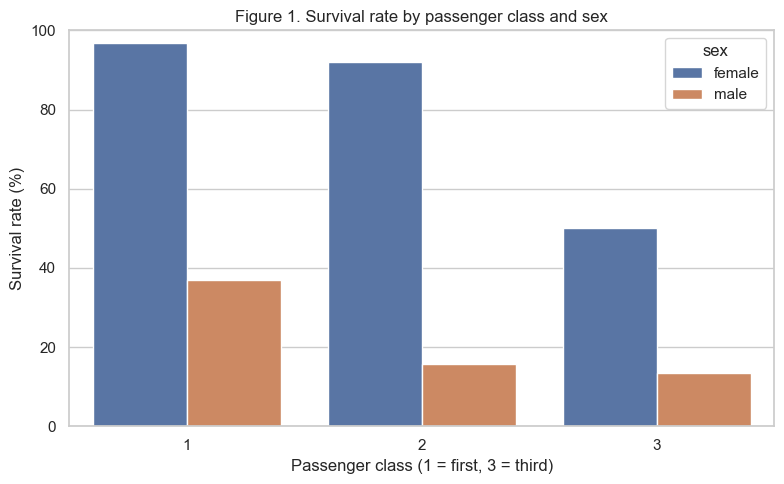

In [15]:
# Figure 1: survival rate by class and sex
fig, ax = plt.subplots(figsize=(8, 5))
rates = survival_rate_by(df, "pclass", "sex").reset_index()
sns.barplot(data=rates, x="pclass", y="survival_rate", hue="sex", ax=ax)
ax.set_title("Figure 1. Survival rate by passenger class and sex")
ax.set_xlabel("Passenger class (1 = first, 3 = third)")
ax.set_ylabel("Survival rate (%)")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_survival_by_class_sex.png", dpi=150)
plt.show()

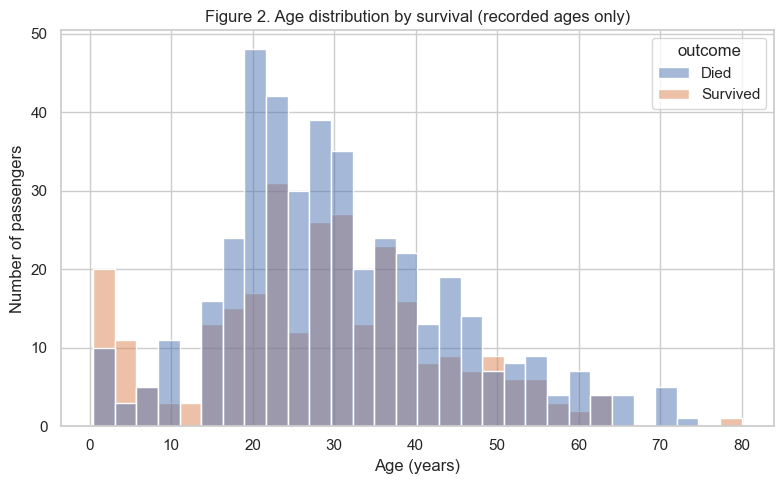

In [16]:
# Figure 2: age distribution of survivors vs non-survivors
# (only passengers with a recorded age, so imputed values don't distort the shape)
fig, ax = plt.subplots(figsize=(8, 5))
known_age = df[~df["age_was_missing"]].assign(
    outcome=lambda t: t["survived"].map({0: "Died", 1: "Survived"}))
sns.histplot(data=known_age, x="age", hue="outcome", hue_order=["Died", "Survived"], bins=30,
             multiple="layer", stat="count", ax=ax)
ax.set_title("Figure 2. Age distribution by survival (recorded ages only)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of passengers")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_age_by_survival.png", dpi=150)
plt.show()

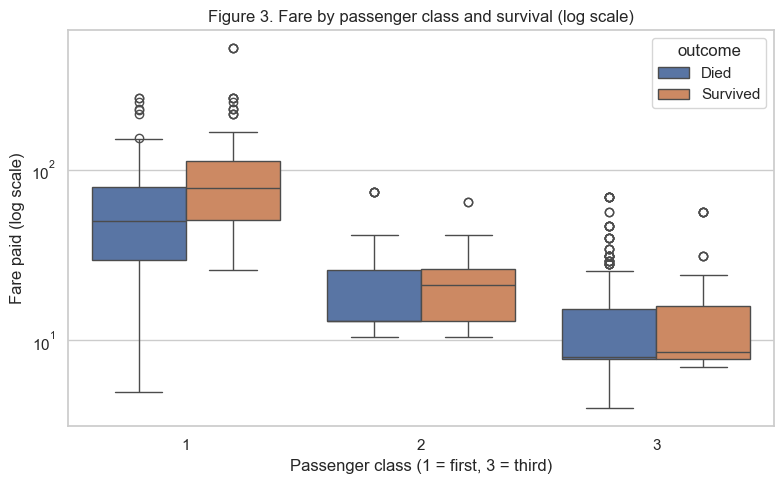

In [17]:
# Figure 3: fare paid by class and survival (log scale because fares are very skewed)
fig, ax = plt.subplots(figsize=(8, 5))
paid = df[df["fare"] > 0].assign(
    outcome=lambda t: t["survived"].map({0: "Died", 1: "Survived"}))
sns.boxplot(data=paid, x="pclass", y="fare", hue="outcome",
            hue_order=["Died", "Survived"], ax=ax)
ax.set_yscale("log")
ax.set_title("Figure 3. Fare by passenger class and survival (log scale)")
ax.set_xlabel("Passenger class (1 = first, 3 = third)")
ax.set_ylabel("Fare paid (log scale)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_fare_by_class_survival.png", dpi=150)
plt.show()

## Task 8: Summary and interpretation

- **What I learned from the dataset:**
  - The dataset has 891 passengers, and only 38.4% of them survived (Table 1).
  - Sex made the biggest difference: women survived far more often than men in every class (96.8% vs 36.9% in first class, 92.1% vs 15.7%
    in second, 50.0% vs 13.5% in third) (Table 4, Figure 1).
  - Class also mattered. Survival was 63.0% in first class, 47.3% in second and 24.2% in third (Table 3, Figure 1). First-class
    passengers also paid much more, with a median fare of about £60 against £14 in second and £8 in third (Table 6).

- **Interesting patterns or insights:**
  - Third-class men were the largest group (347 people) and the worst off, with only 13.5% surviving (Table 4, Figure 1).
  - Survival changed with age. The table below uses recorded ages only (Table 7):

  | Age   | Passengers | Survived |
  |-------|------------|----------|
  | 0–11  | 68         | 57.4%    |
  | 12–17 | 45         | 48.9%    |
  | 18–34 | 366        | 36.9%    |
  | 35–59 | 209        | 41.6%    |
  | 60+   | 26         | 26.9%    |

  - Young children were the only age group where more survived than died (Table 7, Figure 2).
  - Within first class, survivors had paid higher fares than those who died (Figure 3). In second and third class the difference is
    small.
- **Limitations or assumptions:**
  - Some ages were guessed. About 1 in 5 passengers had no age, so I used a typical age for people of the same class and sex. This
    happened most in third class, so third-class age results are less certain (Table 8).
  - No cabin information. Most passengers had no deck recorded, so where people slept on the ship couldn't be checked (Task 5, missing values before cleaning: 77.2%).
  - Some fares were 0. 15 people paid nothing, so they're left out of the fare chart (Table 9, Figure 3).
  - Linked isn't the same as caused. Women, first-class passengers and higher fares all go together, so it's hard to say which one
    really helped people survive.
  - Not everyone is here. The data covers 891 passengers, not the full list of people on board.
- **Anything surprising or unclear:**
  - Women in third class didn't do as well. Even though women were meant to go first, only half of the third-class women survived (Table 4).
  - Middle-aged people did a bit better than young adults. People aged 35–59 survived a little more often than people aged 18–34,
    which is a surprise (Table 7).
  - Some rows look the same. 107 rows match another row exactly. They're probably different people who just happen to have the same
    details, because the data has no names to tell them apart (Task 5, duplicates check).